In [1]:
import numpy as np
import pandas as pd

import mne
from mne.time_frequency import tfr_morlet

import pyeeg
import pywt

import glob

import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (20, 16)})

In [2]:
def find_files(pattern, path):
    return glob.glob(f'{path}/{pattern}')

In [3]:
files = find_files('*.set', '../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/')
print(files[0])
print(len(files))

../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P149.set
51


In [4]:
files[0][-8:-4]

'P149'

In [5]:
# Try one file only
epochs = mne.io.read_epochs_eeglab('../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P133.set')

Extracting parameters from /Users/Daria.Meshcherina/dev/eeg_study_poetry/../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P133.set...


/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_33310/2508770221.py:2: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab('../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P133.set')


Not setting metadata
210 matching events found
No baseline correction applied
0 projection items activated
Ready.


In [6]:
# Define frequency bands
freqs = {
         'delta': (1, 4),
         'theta': (4, 8),
         'alpha': (8, 12),
         'beta': (12, 30), 
         'lower gamma': (30, 48)
        }

n_cycles_dict = {
         'delta': 2,
         'theta': 8,
         'alpha': 8,
         'beta': 8, 
         'lower gamma': 8
}

In [7]:
#len(epochs.ch_names)
print(epochs.ch_names)

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'Afz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2']


In [8]:
# Define ROI clusters
clusters = {
    'CL1': ['AF7', 'AF3', 'F1', 'F3', 'F5', 'F7'],
    'CL2': ['FT7', 'FC3', 'C1', 'CP3', 'TP7', 'T7'],
    'CL3': ['P7', 'P5', 'P3', 'P1', 'PO3', 'PO7'],
    'CL4': ['AF8', 'AF4', 'F2', 'F4', 'F6', 'F8'],
    'CL5': ['FT8', 'FC4', 'C2', 'CP4', 'TP8', 'T8'],
    'CL6': ['P8', 'P6', 'P4', 'P2', 'PO4', 'PO8']
}

Not setting metadata
210 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


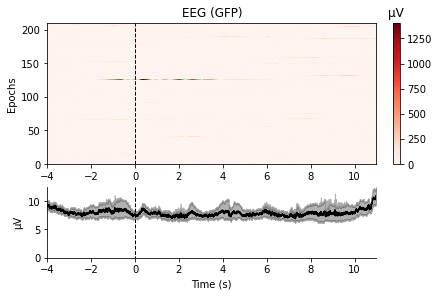

[<Figure size 432x288 with 3 Axes>]

In [9]:
epochs.plot_image()

In [10]:
#for band, fmin_fmax in freqs.items():
#    fmin, fmax = fmin_fmax
#    tfr = epochs.compute_tfr(method='morlet', 
#                             freqs=np.arange(fmin, fmax, 1),
#                             n_cycles=n_cycles_dict[band], 
#                             return_itc=False,
#                             n_jobs=-1, 
#                             verbose=False)
    
#    power = tfr.data.mean(axis=(0, 2, 3))  # Average power over epochs, time, and frequencies
    
#    fig, ax = plt.subplots(1, 1)
#    im, cn = mne.viz.plot_topomap(power, tfr.info, 
#                                  axes=ax, show=False, cmap='viridis')
    
#    fig.colorbar(im)
#    fig.suptitle(f'{band.capitalize()} ({fmin}-{fmax} Hz)', size=12)
#    fig.show()

In [11]:
def compute_features_per_subject(epochs=epochs, clusters=clusters, freqs=freqs):

    features = pd.DataFrame(columns=['epoch','cluster','time_period','frequency_range','mean_power'])
    epoch_list=[]
    cluster_names=[]
    time_periods=[]
    frequency_ranges=[]
    mean_powers=[]

    # Loop over your epochs
    for i in list(range(0,len(epochs))):
        epoch = i+1
        # Loop over your clusters
        for cluster_name, cluster in clusters.items():
            for time_period in [(-4, 0), (0, 5), (5, 10)]:
            
            # Crop the epoch to the current time period
                epoch_cropped = epochs[i].copy().crop(*time_period)
            
            # Pick the channels in the current cluster
                epoch_cluster = epoch_cropped.pick(cluster)
        
            # Loop over your frequency bands
                for band_name, (fmin, fmax) in freqs.items():
                
                # Compute the TFR
                    #print(band_name)
                    #print(n_cycles_dict[band_name])
                    #print(fmin, fmax)
                    power = epoch_cluster.compute_tfr(method='morlet', 
                                                  freqs=np.arange(fmin, fmax), n_cycles=n_cycles_dict[band_name], 
                                                      return_itc=False,
                                                 n_jobs=-1, verbose=False)
            
                # Plots
                #power.plot([0], baseline=(-0.5, 0), mode='logratio', 
                #           title='epoch ' + str(i) + ' cluster '+ str(cluster_name) + ' time' + str(time_period) + ' frequency ' + str(band_name))
                #print('epoch ' + str(epoch) + ' cluster '+ str(cluster_name) + ' time' + str(time_period) + ' frequency ' + str(band_name))
                
                # Compute the mean power
                    mean_power = power.data.mean()
            
                # Store the mean power and the features lists
                    epoch_list.append(epoch)
                    cluster_names.append(cluster_name)
                    time_periods.append(time_period)
                    frequency_ranges.append(band_name)
                    mean_powers.append(mean_power)
                
    features['epoch']=epoch_list
    features['cluster']=cluster_names
    features['time_period']=time_periods
    features['frequency_range']=frequency_ranges
    features['mean_power']=mean_powers
    
    return features

In [12]:
# Loop the function over all subjects

df_features = pd.DataFrame(columns=['subject_name','epoch','cluster','time_period','frequency_range','mean_power'])

for i,file in enumerate(files):
    
    subject_name = str(file[-8:-4])
    print("Computing features file for subject ", subject_name, "number ", i, "out of 51")
    epochs = mne.io.read_epochs_eeglab(file)
    features = compute_features_per_subject(epochs=epochs, clusters=clusters, freqs=freqs)
    features['subject_name'] = subject_name
    
    df_features = pd.concat([df_features,features], ignore_index=True)

Computing features file for subject  P149 number  0 out of 51
Extracting parameters from /Users/Daria.Meshcherina/dev/eeg_study_poetry/../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P149.set...


/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_33310/518550058.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file)


Not setting metadata
210 matching events found
No baseline correction applied
0 projection items activated
Ready.
Computing features file for subject  P148 number  1 out of 51
Extracting parameters from /Users/Daria.Meshcherina/dev/eeg_study_poetry/../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P148.set...


/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_33310/518550058.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file)


Not setting metadata
210 matching events found
No baseline correction applied
0 projection items activated
Ready.
Computing features file for subject  P107 number  2 out of 51
Extracting parameters from /Users/Daria.Meshcherina/dev/eeg_study_poetry/../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P107.set...


...

Not setting metadata
210 matching events found
No baseline correction applied
0 projection items activated
Ready.
Computing features file for subject  P140 number  49 out of 51
Extracting parameters from /Users/Daria.Meshcherina/dev/eeg_study_poetry/../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P140.set...


/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_33310/518550058.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file)


Not setting metadata
210 matching events found
No baseline correction applied
0 projection items activated
Ready.
Computing features file for subject  P141 number  50 out of 51
Extracting parameters from /Users/Daria.Meshcherina/dev/eeg_study_poetry/../project_eeg/data/Haiku_Senryu_EEG/ICA_Pruned_Datasets/ICA_Pruned_P141.set...


/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_33310/518550058.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file)


Not setting metadata
209 matching events found
No baseline correction applied
0 projection items activated
Ready.


In [13]:
df_features.shape

(963810, 6)

In [14]:
df_features.head()

,subject_name,epoch,cluster,time_period,frequency_range,mean_power
0,P149,1,CL1,"(-4, 0)",delta,6.613142e-09
1,P149,1,CL1,"(-4, 0)",theta,1.042548e-09
2,P149,1,CL1,"(-4, 0)",alpha,6.790457e-10
3,P149,1,CL1,"(-4, 0)",beta,2.765609e-10
4,P149,1,CL1,"(-4, 0)",lower gamma,8.716803e-11


In [15]:
df_features.to_csv('../project_eeg/data/computed_features/mean_power_morlet_wavelets_with_delta_theta.csv',
                   index=False)